<a href="https://colab.research.google.com/github/SerynaPayne/Seryna_INFO4670_Spring2026/blob/main/Seryna_Payne_Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# load data
data = pd.read_csv('car_purchase_data.csv')
display(data.head())
print('Shape:', data.shape)

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


Shape: (400, 5)


### Step 2: Split features and target

In [2]:
# split features and target
X = data[['Age', 'Salary',]] # only using age and salary for prediction
y = data['Purchased']

print('X shape:', X.shape)
print('y distribution:\n', y.value_counts())

X shape: (400, 2)
y distribution:
 Purchased
0    257
1    143
Name: count, dtype: int64


### Step 3: Train/Test Split

In [12]:
# train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.16, random_state=10, stratify=y
)
print('Train size:', X_train.shape[0], ' Test size:', X_test.shape[0])

Train size: 336  Test size: 64


### Step 4: Feature Scaling

In [13]:
# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print('Scaling complete.')

Scaling complete.


### Step 5: Train Logistic Regression Model

In [14]:
# model training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print('Model trained.')

Model trained.


### Step 6: Predict and Evaluate

In [15]:
# predict
y_pred = model.predict(X_test)

# evaluate
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print('Accuracy:', acc)
print('\nConfusion Matrix:\n', cm)
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.90625

Confusion Matrix:
 [[39  2]
 [ 4 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93        41
           1       0.90      0.83      0.86        23

    accuracy                           0.91        64
   macro avg       0.91      0.89      0.90        64
weighted avg       0.91      0.91      0.91        64



### Step 7: Visualization of Decision Regions

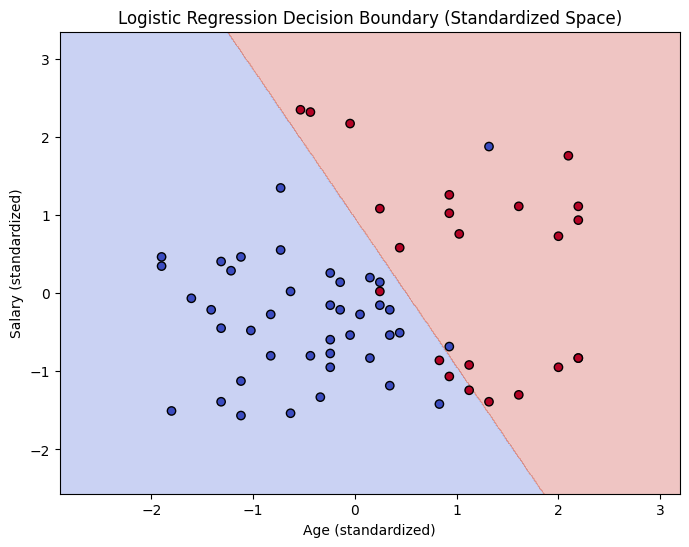

In [16]:
# visualization
import numpy as np
import matplotlib.pyplot as plt

X_set, y_set = X_test[:, :2], y_test.values
model_2d = LogisticRegression(max_iter=1000)
model_2d.fit(X_train[:, :2], y_train)

x1_min, x1_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
x2_min, x2_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
X1, X2 = np.meshgrid(
    np.arange(start=x1_min, stop=x1_max, step=0.01),
    np.arange(start=x2_min, stop=x2_max, step=0.01)
)

Z = model_2d.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

plt.figure(figsize=(8,6))
plt.contourf(X1, X2, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, edgecolor='k', cmap='coolwarm')
plt.title('Logistic Regression Decision Boundary (Standardized Space)')
plt.xlabel('Age (standardized)')
plt.ylabel('Salary (standardized)')
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. Logistic regression can still be used for classification because we assign a class based on the probability. From the cutoff point that we set, anything below is class 0 and anything above is class 1, so in this case, if a customer is predicted to buy a car, they are class 1, and if a customer is predicted to not buy a car, they are class 0 from the logistic function we used.

2. By looking at the model, the customers that are more likely to purchase a car are those who are older with a higher salary. It appears that if someone is younger, they would need the higher salary out of those in their age in order to be likely to purchase a car. If someone is older, their salary has a much larger range to be predicted to buy a car. This means that if the age is below 1 on the standardized logistic regression model, their salary is what would determine how likely they are to purchase a car.

3. Factors that may cause low accuracy in this task can be an ill-fitting test size, causing the training size and test size to have too much of a difference, and not using proper data cleaning and preprocessing steps, such as deciding whether to drop outliers.

4. Additional features or preprocessing steps that could improve accuracy include firstly, adding more data, and treating missing and outlier values as I stated in step 3. It would also be logical to use other higher-quality datasets investigating this probability in comparison.
